<a href="https://colab.research.google.com/github/Amary754/gaming-analysis/blob/main/analysis_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Video Game Market Analysis

**Author:** Amar Gautam
**Tools:** Python (Pandas, Matplotlib, Seaborn), SQL (SQLite)
**Dataset:** Video Game Sales (Kaggle), `vgsales.csv`

## Problem Statement
A new game studio wants to know which genres, platforms, and regions to focus on, based on historical video game sales.

## Business Questions
1. Which genres have the highest global sales?
2. How have total sales changed year by year?
3. Which platforms sell the most?
4. Which publishers dominate the market?
5. Do North America, Europe, and Japan prefer different genres?

> **How to run:** upload `vgsales.csv` in the Colab Files panel, then click **Runtime > Run all**.

## 1. Load the Data

In [1]:
import os
import pandas as pd

# Try the common places where the file may be (Colab root, /content, local folders)
paths = ["vgsales.csv", "/vgsales.csv", "/content/vgsales.csv", "../data/vgsales.csv", "data/vgsales.csv"]
data_path = next((p for p in paths if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError("vgsales.csv not found. Upload it in the Files panel (folder icon) and run again.")

df = pd.read_csv(data_path)
print("Loaded from:", data_path)
df.head()

Loaded from: vgsales.csv


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 2. Understand the Data

In [2]:
print("Rows, columns:", df.shape)
df.info()

Rows, columns: (16598, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [3]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


## 3. Clean the Data
Steps: remove duplicates, drop rows with a missing Year or Publisher, fix data types, and remove extra spaces in text columns. I work on a copy so the raw data stays untouched.

In [4]:
df_clean = df.copy()
original_rows = len(df_clean)

# 1. Duplicates
duplicates = int(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()

# 2. Missing Year or Publisher (only a small share of rows, so dropping is safe)
before = len(df_clean)
df_clean = df_clean.dropna(subset=["Year", "Publisher"])
missing_removed = before - len(df_clean)

# 3. Data types: Year from decimal (2006.0) to integer (2006)
df_clean["Year"] = df_clean["Year"].astype(int)

# 4. Remove extra spaces in text columns
for col in ["Name", "Platform", "Genre", "Publisher"]:
    df_clean[col] = df_clean[col].str.strip()

df_clean = df_clean.reset_index(drop=True)

print("Original rows:", original_rows)
print("Duplicates removed:", duplicates)
print("Rows with missing Year/Publisher removed:", missing_removed)
print("Final rows:", len(df_clean))

Original rows: 16598
Duplicates removed: 0
Rows with missing Year/Publisher removed: 307
Final rows: 16291


In [5]:
# Sanity checks
print("Year range:", df_clean["Year"].min(), "to", df_clean["Year"].max())
print("Rows with sales <= 0:", (df_clean["Global_Sales"] <= 0).sum())
print("Missing values in cleaned data:", int(df_clean.isnull().sum().sum()))

Year range: 1980 to 2020
Rows with sales <= 0: 0
Missing values in cleaned data: 0


In [6]:
df_clean.to_csv("vgsales_clean.csv", index=False)
print("Saved vgsales_clean.csv")

Saved vgsales_clean.csv


### Cleaning Summary
- Original rows: **16,598**
- Duplicates removed: **0**
- Rows with missing Year or Publisher removed: **307** (about 1.8% of the data)
- Year converted from decimal to integer
- Extra spaces removed from text columns
- Final rows: **16,291**

*Why drop instead of fill?* Year and Publisher cannot be guessed reliably, and the removed rows are under 2% of the data, so the results are barely affected.

## 4. Exploratory Analysis

In [7]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
os.makedirs("charts", exist_ok=True)   # all charts are saved in this folder

### Question 1: Which genres have the highest global sales?

In [8]:
genre_sales = (df_clean.groupby("Genre")["Global_Sales"]
               .sum()
               .sort_values(ascending=False))
genre_sales.round(2)

,Global_Sales
Genre,
Action,1722.84
Sports,1309.24
Shooter,1026.20
Role-Playing,923.83
Platform,829.13
Misc,789.87
Racing,726.76
Fighting,444.05
Simulation,389.98


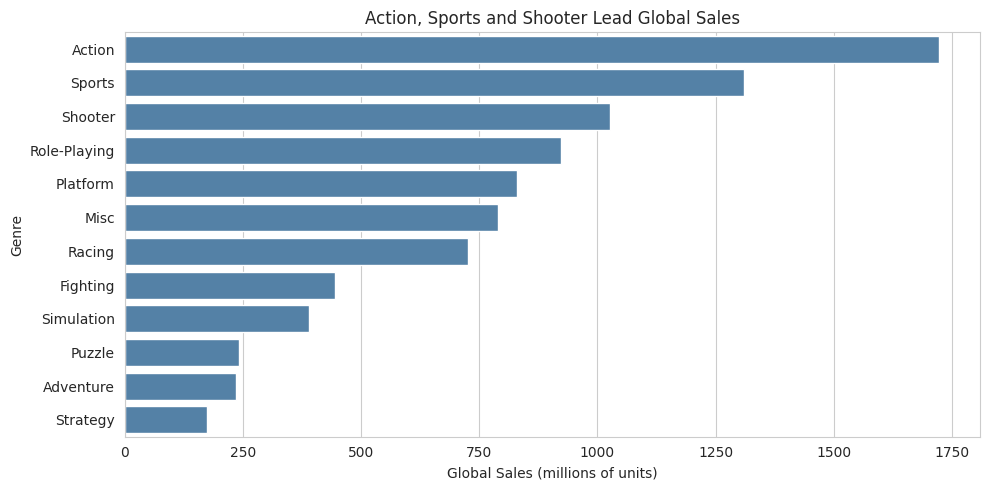

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(x=genre_sales.values, y=genre_sales.index, color="steelblue")
plt.title("Action, Sports and Shooter Lead Global Sales")
plt.xlabel("Global Sales (millions of units)")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("charts/q1_genre_sales.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Action is the top genre with about 1,723M units, followed by Sports (1,309M) and Shooter (1,026M). These three genres together account for roughly 4,060M units.

**Why it matters:** These are the proven high-volume genres, so a new studio has the largest market here. Total sales alone can mislead, though, because Action also has the most games (3,251). See the average sales per game below.

In [10]:
# Total sales can be high just because a genre has many games. Check sales per game too.
genre_stats = df_clean.groupby("Genre")["Global_Sales"].agg(total_sales="sum", num_games="count", avg_per_game="mean")
genre_stats = genre_stats.sort_values("avg_per_game", ascending=False).round(2)
genre_stats

,total_sales,num_games,avg_per_game
Genre,,,
Platform,829.13,875,0.95
Shooter,1026.20,1282,0.80
Role-Playing,923.83,1470,0.63
Racing,726.76,1225,0.59
Sports,1309.24,2304,0.57
Fighting,444.05,836,0.53
Action,1722.84,3251,0.53
Misc,789.87,1686,0.47
Simulation,389.98,848,0.46


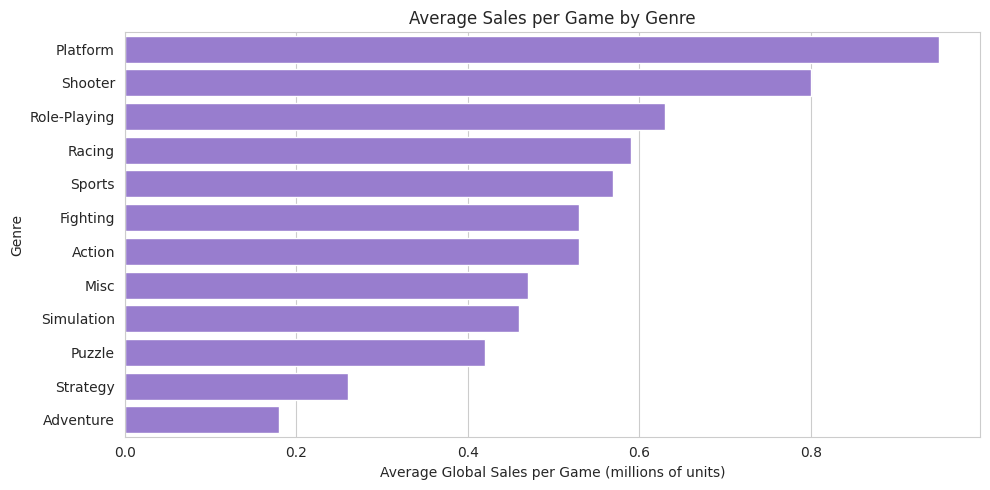

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(x=genre_stats["avg_per_game"], y=genre_stats.index, color="mediumpurple")
plt.title("Average Sales per Game by Genre")
plt.xlabel("Average Global Sales per Game (millions of units)")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("charts/q1b_avg_sales_per_game.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Per game, Platform (about 0.95M) and Shooter (about 0.80M) earn the most, ahead of Action (about 0.53M). Adventure and Strategy earn the least per game.

**Why it matters:** Action leads in total because so many Action games exist, not because each one sells best. Shooter and Platform games give a higher return per release, so a studio with a small portfolio may do better there than in the crowded Action market.

### Question 2: How have sales changed year by year?

In [12]:
yearly = df_clean.groupby("Year").agg(total_sales=("Global_Sales", "sum"), games_released=("Name", "count")).round(2)
print("Peak year:", yearly["total_sales"].idxmax(), "with", yearly["total_sales"].max(), "million units")
yearly.tail(8)

Peak year: 2008 with 678.9 million units


,total_sales,games_released
Year,,
2011,515.80,1136
2012,363.49,655
2013,368.11,546
2014,337.03,580
2015,264.44,614
2016,70.90,342
2017,0.05,3
2020,0.29,1


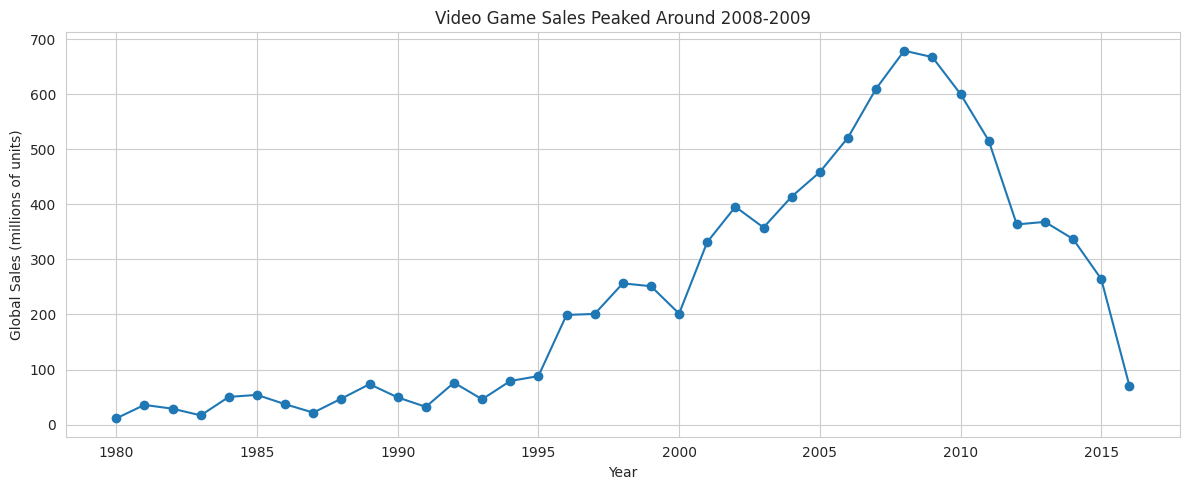

In [13]:
# The last years in this dataset are incomplete (2017 has only a few games, 2020 only one),
# so the chart stops at 2016.
trend = yearly[yearly.index <= 2016]

plt.figure(figsize=(12, 5))
plt.plot(trend.index, trend["total_sales"], marker="o")
plt.title("Video Game Sales Peaked Around 2008-2009")
plt.xlabel("Year")
plt.ylabel("Global Sales (millions of units)")
plt.tight_layout()
plt.savefig("charts/q2_yearly_sales.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Sales grew steadily from the mid-1990s and peaked in 2008 (about 679M units), with 2009 almost as high (667M). After 2011 sales fell to about 264M by 2015. The numbers for 2016 and later are incomplete (342 games in 2016, only 3 in 2017, 1 in 2020), so the sharp drop there is partly missing data, not a real crash.

**Why it matters:** Physical-era sales peaked more than ten years ago, so this dataset shows past market structure, not today's. A studio should treat it as a guide to what has sold well, and check recent digital and mobile data before deciding.

### Question 3: Which platforms sell the most?

In [14]:
platform_sales = (df_clean.groupby("Platform")["Global_Sales"]
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))
platform_sales.round(2)

,Global_Sales
Platform,
PS2,1233.46
X360,969.60
PS3,949.35
Wii,909.81
DS,818.91
PS,727.39
GBA,305.62
PSP,291.71
PS4,278.10


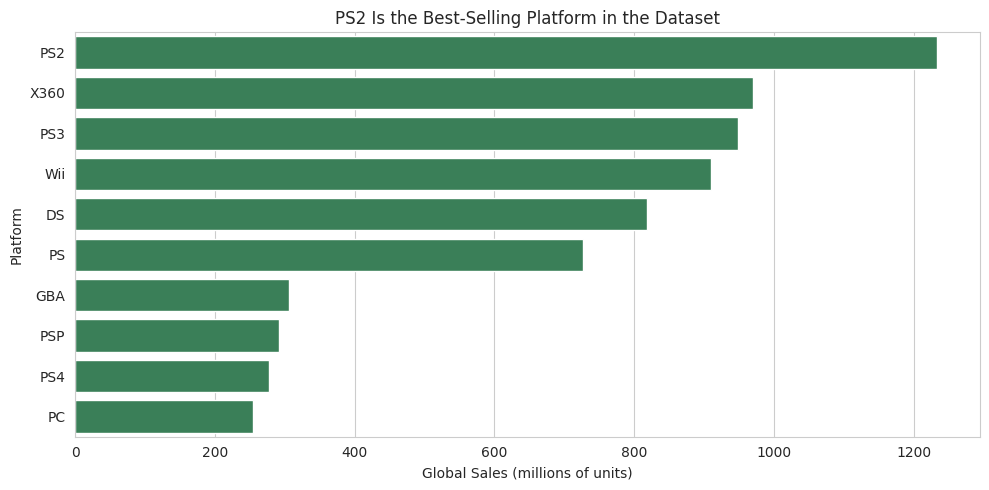

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(x=platform_sales.values, y=platform_sales.index, color="seagreen")
plt.title("PS2 Is the Best-Selling Platform in the Dataset")
plt.xlabel("Global Sales (millions of units)")
plt.ylabel("Platform")
plt.tight_layout()
plt.savefig("charts/q3_platform_sales.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** PS2 leads with about 1,233M units, followed by Xbox 360 (970M), PS3 (949M), and Wii (910M). Sony, Microsoft, and Nintendo platforms fill the top ten. PS4 appears low (278M) mainly because the dataset ends before its life cycle finished.

**Why it matters:** Console platforms from the big three dominate sales, so a game released on several major consoles reaches the largest audience. Newer platforms are under-counted here, so use recent data before choosing a launch platform.

### Question 4: Which publishers dominate the market?

In [16]:
publisher_stats = df_clean.groupby("Publisher")["Global_Sales"].agg(total_sales="sum", num_games="count")
publisher_stats["avg_per_game"] = publisher_stats["total_sales"] / publisher_stats["num_games"]
top_publishers = publisher_stats.sort_values("total_sales", ascending=False).head(10).round(2)
top_publishers

,total_sales,num_games,avg_per_game
Publisher,,,
Nintendo,1784.43,696,2.56
Electronic Arts,1093.39,1339,0.82
Activision,721.41,966,0.75
Sony Computer Entertainment,607.28,682,0.89
Ubisoft,473.54,918,0.52
Take-Two Interactive,399.30,412,0.97
THQ,340.44,712,0.48
Konami Digital Entertainment,278.56,823,0.34
Sega,270.70,632,0.43


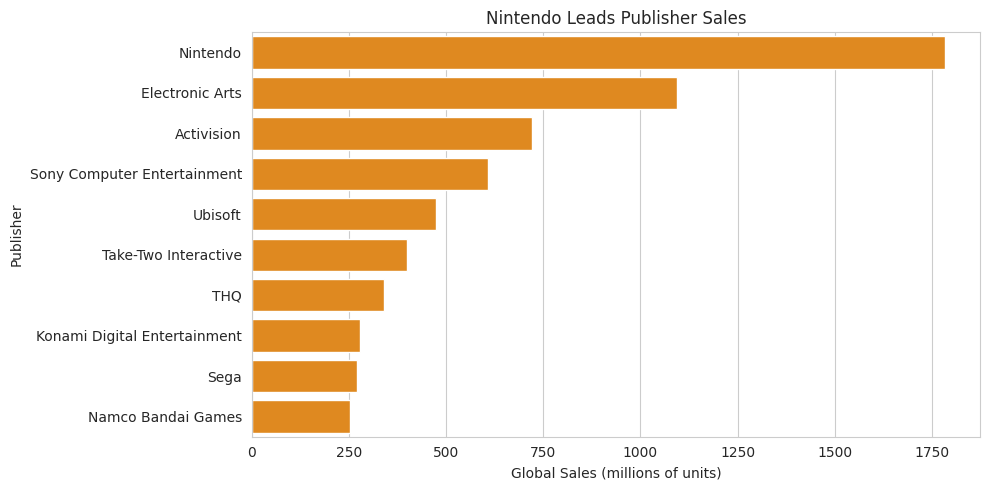

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_publishers["total_sales"], y=top_publishers.index, color="darkorange")
plt.title("Nintendo Leads Publisher Sales")
plt.xlabel("Global Sales (millions of units)")
plt.ylabel("Publisher")
plt.tight_layout()
plt.savefig("charts/q4_publisher_sales.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Nintendo leads with about 1,784M units from 696 games, around 2.6M per game. Electronic Arts is second (1,093M) but needed 1,339 games, around 0.8M per game. Activision, Sony Computer Entertainment, and Ubisoft complete the top five.

**Why it matters:** Nintendo wins through strong franchises, not volume, while EA wins through a wide catalog. A new studio cannot match the catalog of large publishers, so it should compete on a few high-quality titles.

### Question 5: Do regions prefer different genres?

In [18]:
region_genre = df_clean.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales"]].sum().round(2)
region_genre

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,861.77,516.48,158.65
Adventure,101.93,63.74,51.99
Fighting,220.74,100.00,87.15
Misc,396.92,211.77,106.67
Platform,445.99,200.65,130.65
Puzzle,122.01,50.52,56.68
Racing,356.93,236.31,56.61
Role-Playing,326.50,187.57,350.29
Shooter,575.16,310.45,38.18


In [19]:
region_pct = (region_genre.div(region_genre.sum()) * 100).round(1)
region_pct

,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,19.9,21.5,12.4
Adventure,2.4,2.6,4.0
Fighting,5.1,4.2,6.8
Misc,9.2,8.8,8.3
Platform,10.3,8.3,10.2
Puzzle,2.8,2.1,4.4
Racing,8.2,9.8,4.4
Role-Playing,7.5,7.8,27.3
Shooter,13.3,12.9,3.0


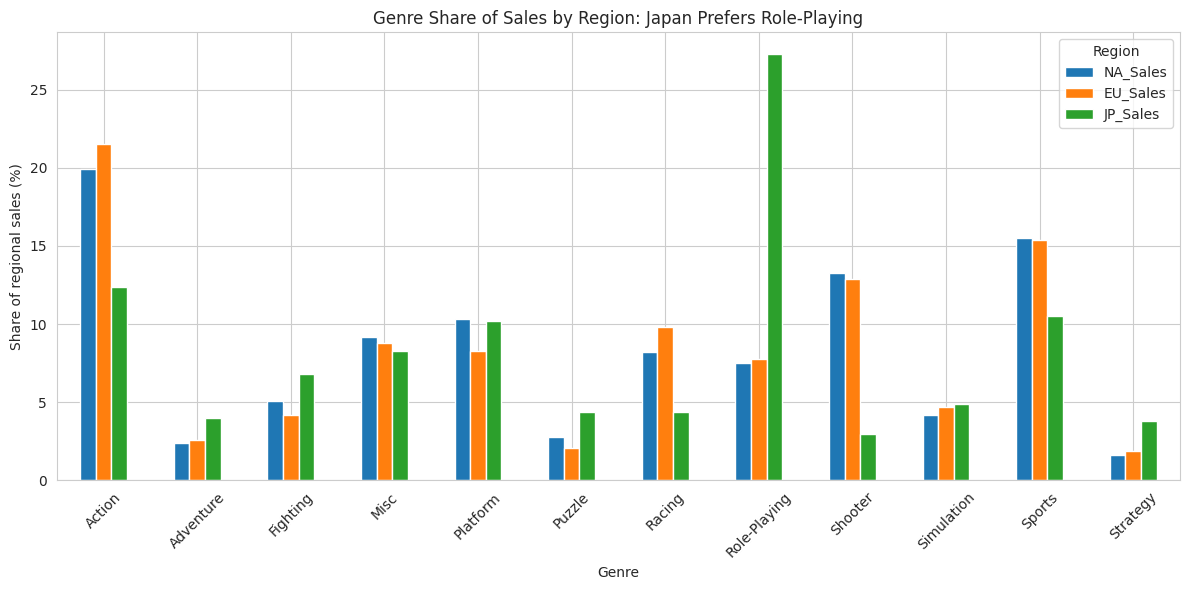

In [20]:
region_pct.plot(kind="bar", figsize=(12, 6))
plt.title("Genre Share of Sales by Region: Japan Prefers Role-Playing")
plt.ylabel("Share of regional sales (%)")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.tight_layout()
plt.savefig("charts/q5_region_genre_share.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** North America and Europe look alike: Action, Sports, and Shooter lead in both. Japan is different. Role-Playing is its top genre (about 350M units, 27% of Japan's sales, versus 7.5% in North America), and Shooter makes up only 3% of Japan's sales versus 13% in North America.

**Why it matters:** A shooter or action game fits Western markets, while Japan needs a role-playing focus. A studio should choose its target region before choosing its genre. I used percentage shares because Japan sells fewer games overall, which makes raw totals unfair to compare.

## 5. SQL Analysis
The same questions, answered with SQL (SQLite). The results should match the Pandas results above, which confirms the analysis is correct.

In [21]:
import sqlite3

conn = sqlite3.connect("games.db")
df_clean.to_sql("games", conn, if_exists="replace", index=False)

def run(query):
    return pd.read_sql_query(query, conn)

run("SELECT COUNT(*) AS rows_in_table FROM games;")

,rows_in_table
0,16291


In [22]:
# All SQL queries are stored here once. They are run below and also saved into queries.sql.
queries = {
"Q1: Top genres by global sales": """
SELECT Genre,
       ROUND(SUM(Global_Sales), 2) AS total_sales,
       COUNT(*) AS num_games
FROM games
GROUP BY Genre
ORDER BY total_sales DESC;
""",
"Q2: Sales and games released by year": """
SELECT Year,
       ROUND(SUM(Global_Sales), 2) AS total_sales,
       COUNT(*) AS games_released
FROM games
GROUP BY Year
ORDER BY Year;
""",
"Q3: Top 10 platforms": """
SELECT Platform,
       ROUND(SUM(Global_Sales), 2) AS total_sales
FROM games
GROUP BY Platform
ORDER BY total_sales DESC
LIMIT 10;
""",
"Q4: Top 10 publishers": """
SELECT Publisher,
       ROUND(SUM(Global_Sales), 2) AS total_sales,
       COUNT(*) AS num_games
FROM games
GROUP BY Publisher
ORDER BY total_sales DESC
LIMIT 10;
""",
"Q5: Regional sales by genre": """
SELECT Genre,
       ROUND(SUM(NA_Sales), 2) AS north_america,
       ROUND(SUM(EU_Sales), 2) AS europe,
       ROUND(SUM(JP_Sales), 2) AS japan
FROM games
GROUP BY Genre
ORDER BY north_america DESC;
""",
"Extra 1: Average sales per game by genre (genres with at least 50 games)": """
SELECT Genre,
       COUNT(*) AS num_games,
       ROUND(AVG(Global_Sales), 2) AS avg_sales_per_game
FROM games
GROUP BY Genre
HAVING COUNT(*) >= 50
ORDER BY avg_sales_per_game DESC;
""",
"Extra 2: Top 10 best-selling games": """
SELECT Name, Platform, Year, Genre, Global_Sales
FROM games
ORDER BY Global_Sales DESC
LIMIT 10;
""",
"Extra 3: Best-selling platform in each year (window function)": """
WITH yearly AS (
    SELECT Year, Platform, SUM(Global_Sales) AS sales
    FROM games
    GROUP BY Year, Platform
),
ranked AS (
    SELECT Year, Platform, ROUND(sales, 2) AS sales,
           ROW_NUMBER() OVER (PARTITION BY Year ORDER BY sales DESC) AS rn
    FROM yearly
)
SELECT Year, Platform, sales
FROM ranked
WHERE rn = 1
ORDER BY Year;
""",
}
print(len(queries), "queries ready")

8 queries ready


### SQL Q1: Top genres by global sales

In [23]:
run(queries["Q1: Top genres by global sales"])

,Genre,total_sales,num_games
0,Action,1722.84,3251
1,Sports,1309.24,2304
2,Shooter,1026.20,1282
3,Role-Playing,923.83,1470
4,Platform,829.13,875
5,Misc,789.87,1686
6,Racing,726.76,1225
7,Fighting,444.05,836
8,Simulation,389.98,848
9,Puzzle,242.21,570


### SQL Q2: Sales by year

In [24]:
run(queries["Q2: Sales and games released by year"])

,Year,total_sales,games_released
0,1980,11.38,9
1,1981,35.77,46
2,1982,28.86,36
3,1983,16.79,17
4,1984,50.36,14
5,1985,53.94,14
6,1986,37.07,21
7,1987,21.74,16
8,1988,47.22,15
9,1989,73.45,17


### SQL Q3: Top 10 platforms

In [25]:
run(queries["Q3: Top 10 platforms"])

,Platform,total_sales
0,PS2,1233.46
1,X360,969.60
2,PS3,949.35
3,Wii,909.81
4,DS,818.91
5,PS,727.39
6,GBA,305.62
7,PSP,291.71
8,PS4,278.10
9,PC,254.70


### SQL Q4: Top 10 publishers

In [26]:
run(queries["Q4: Top 10 publishers"])

,Publisher,total_sales,num_games
0,Nintendo,1784.43,696
1,Electronic Arts,1093.39,1339
2,Activision,721.41,966
3,Sony Computer Entertainment,607.28,682
4,Ubisoft,473.54,918
5,Take-Two Interactive,399.30,412
6,THQ,340.44,712
7,Konami Digital Entertainment,278.56,823
8,Sega,270.70,632
9,Namco Bandai Games,253.65,928


### SQL Q5: Regional preferences by genre

In [27]:
run(queries["Q5: Regional sales by genre"])

,Genre,north_america,europe,japan
0,Action,861.77,516.48,158.65
1,Sports,670.09,371.34,134.76
2,Shooter,575.16,310.45,38.18
3,Platform,445.99,200.65,130.65
4,Misc,396.92,211.77,106.67
5,Racing,356.93,236.31,56.61
6,Role-Playing,326.50,187.57,350.29
7,Fighting,220.74,100.00,87.15
8,Simulation,181.78,113.02,63.54
9,Puzzle,122.01,50.52,56.68
